In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [62]:
# Make the corner plot for the MCMC results
system_name = 'J0803'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'z', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [63]:
samples

,chi2,z,vel_disp,x,y,ellip,pa
0,5.144726,1.048300,216.8096,-0.652481,0.076534,0.594819,-82.63359
1,5.592987,1.047911,216.8016,-0.653485,0.076716,0.591378,-82.67296
2,5.795128,1.043801,216.8054,-0.653428,0.076568,0.594664,-82.64220
3,5.261177,1.047638,216.7992,-0.653312,0.076416,0.593896,-82.67597
4,5.323407,1.046481,216.7978,-0.652745,0.077354,0.594079,-82.65269
...,...,...,...,...,...,...,...
5887,10.419000,1.055656,216.5086,-0.635804,0.080228,0.570227,-82.95753
5888,9.313355,1.051557,216.5047,-0.635872,0.079842,0.575104,-82.91163
5889,9.174675,1.056385,216.5079,-0.636342,0.079418,0.572748,-82.83148
5890,11.745660,1.051318,216.4977,-0.637045,0.078861,0.568672,-82.77912


In [64]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [60]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

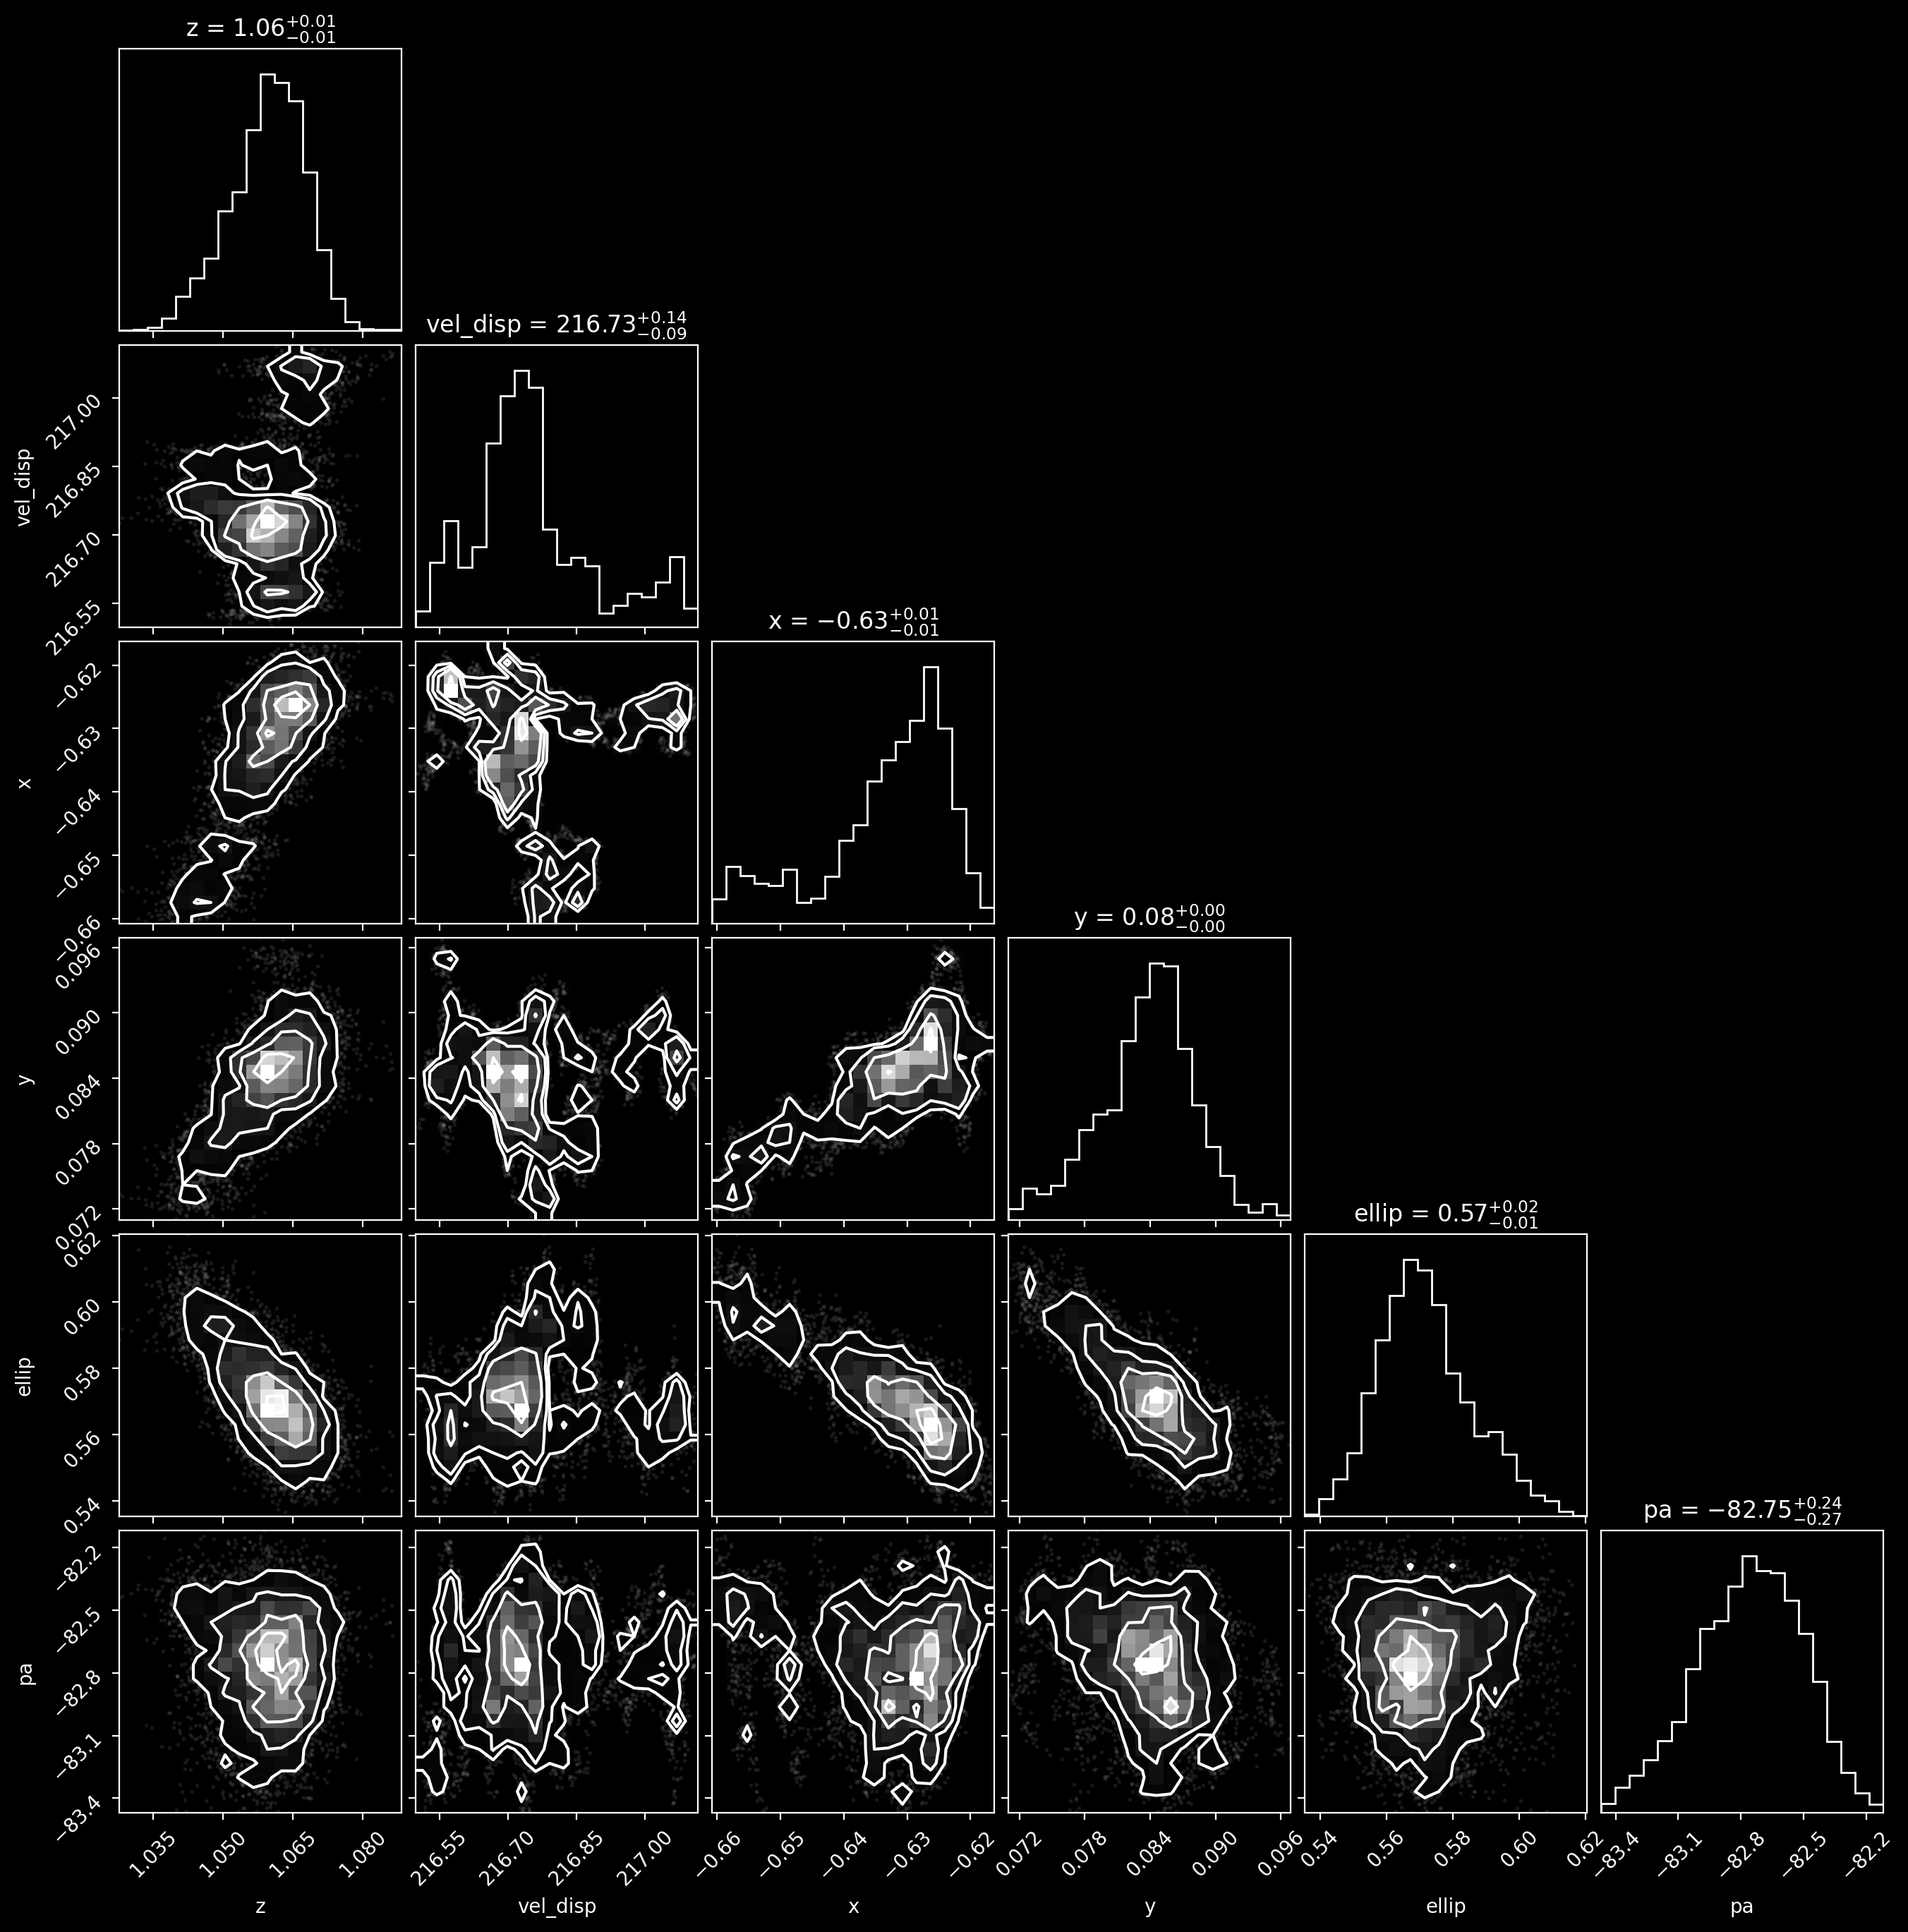

In [65]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['z', 'vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')